In [1]:
!pip install pymysql sqlalchemy

In [2]:
import pandas as pd
from sqlalchemy import create_engine

# 1. Setup your database login credentials
# CRITICAL: Change 'your_password_here' to your actual MySQL root password!
DB_USER = "root"
DB_PASSWORD = "root" 
DB_HOST = "localhost"
DB_PORT = "3306"
DB_NAME = "hal_mro_analytics"

# 2. Fire up the connection bridge
connection_string = f"mysql+pymysql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
db_engine = create_engine(connection_string)

# 3. Pull the data from your advanced SQL view
query = "SELECT * FROM calculated_engine_analytics;"
df = pd.read_sql(query, db_engine)

# 4. Display the first 5 rows right here on the screen
df.head()

,Engine_ID,Current_Flight,Failure_Flight,Remaining_Useful_Life,Maintenance_Status,Core_Speed,LPT_Outlet_Temp,HPC_Outlet_Pressure,Fan_Speed,Throttle_Resolver_Angle,HPT_Cooling_Bleed
0,1,1,192,191,GREEN (Healthy),641.82,1589.70,1400.60,554.36,47.47,521.66
1,1,2,192,190,GREEN (Healthy),642.15,1591.82,1403.14,553.75,47.49,522.28
2,1,3,192,189,GREEN (Healthy),642.35,1587.99,1404.20,554.26,47.27,522.42
3,1,4,192,188,GREEN (Healthy),642.35,1582.79,1401.87,554.45,47.13,522.86
4,1,5,192,187,GREEN (Healthy),642.37,1582.85,1406.22,554.00,47.28,522.19


In [3]:
import pandas as pd
from sqlalchemy import create_engine

# 1. Setup your database login credentials
# CRITICAL: Change 'your_password_here' to your actual MySQL root password!
DB_USER = "root"
DB_PASSWORD = "root" 
DB_HOST = "localhost"
DB_PORT = "3306"
DB_NAME = "hal_mro_analytics"

# 2. Fire up the connection bridge
connection_string = f"mysql+pymysql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
db_engine = create_engine(connection_string)

# 3. Pull the data from your advanced SQL view
query = "SELECT * FROM calculated_engine_analytics;"
df = pd.read_sql(query, db_engine)

# 4. Display the first 5 rows right here on the screen
df.head()

,Engine_ID,Current_Flight,Failure_Flight,Remaining_Useful_Life,Maintenance_Status,Core_Speed,LPT_Outlet_Temp,HPC_Outlet_Pressure,Fan_Speed,Throttle_Resolver_Angle,HPT_Cooling_Bleed
0,1,1,192,191,GREEN (Healthy),641.82,1589.70,1400.60,554.36,47.47,521.66
1,1,2,192,190,GREEN (Healthy),642.15,1591.82,1403.14,553.75,47.49,522.28
2,1,3,192,189,GREEN (Healthy),642.35,1587.99,1404.20,554.26,47.27,522.42
3,1,4,192,188,GREEN (Healthy),642.35,1582.79,1401.87,554.45,47.13,522.86
4,1,5,192,187,GREEN (Healthy),642.37,1582.85,1406.22,554.00,47.28,522.19


In [4]:
# --- Summary Statistics ---
print("\n=== Fleet Health Summary ===")
print(df['Maintenance_Status'].value_counts())

# --- Engines currently in RED ALERT ---
red_alert = df[df['Maintenance_Status'] == 'RED ALERT (Fix Immediately)']
print(f"\nEngines needing immediate attention: {red_alert['Engine_ID'].nunique()}")

# --- Latest status of each engine (most recent cycle only) ---
latest = df.sort_values('Current_Flight').groupby('Engine_ID').last().reset_index()
print("\nLatest RUL per engine:")
print(latest[['Engine_ID', 'Current_Flight', 'Remaining_Useful_Life', 'Maintenance_Status']])


=== Fleet Health Summary ===
Maintenance_Status
GREEN (Healthy)                        12531
YELLOW ALERT (Schedule Maintenance)     5000
RED ALERT (Fix Immediately)             3100
Name: count, dtype: int64

Engines needing immediate attention: 100

Latest RUL per engine:
    Engine_ID  Current_Flight  Remaining_Useful_Life  \
0           1             192                      0   
1           2             287                      0   
2           3             179                      0   
3           4             189                      0   
4           5             269                      0   
..        ...             ...                    ...   
95         96             336                      0   
96         97             202                      0   
97         98             156                      0   
98         99             185                      0   
99        100             200                      0   

             Maintenance_Status  
0   RED ALERT (Fi

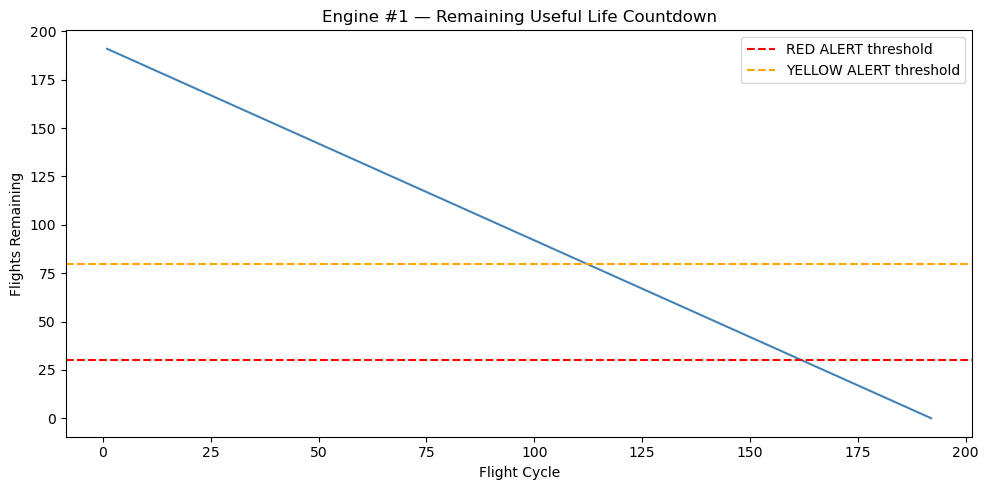

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot 1: RUL Countdown for a single engine
engine1 = df[df['Engine_ID'] == 1]
plt.figure(figsize=(10, 5))
plt.plot(engine1['Current_Flight'], engine1['Remaining_Useful_Life'], color='steelblue')
plt.axhline(y=30, color='red', linestyle='--', label='RED ALERT threshold')
plt.axhline(y=80, color='orange', linestyle='--', label='YELLOW ALERT threshold')
plt.title('Engine #1 — Remaining Useful Life Countdown')
plt.xlabel('Flight Cycle')
plt.ylabel('Flights Remaining')
plt.legend()
plt.tight_layout()
plt.savefig('engine1_rul.png')
plt.show()

In [7]:
# Export latest engine status to Excel — great for presenting to coordinators
latest.to_excel('fleet_health_report.xlsx', index=False)
print("Report saved!")

Report saved!


In [8]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import numpy as np

# Features (sensor readings) and Target (RUL)
features = ['Core_Speed', 'LPT_Outlet_Temp', 'HPC_Outlet_Pressure', 
            'Fan_Speed', 'Throttle_Resolver_Angle', 'HPT_Cooling_Bleed']

X = df[features]
y = df['Remaining_Useful_Life']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluate
predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
print(f"✅ Model Trained Successfully!")
print(f"📊 Mean Absolute Error: {mae:.2f} flight cycles")
print(f"   (Model's predictions are off by only ~{mae:.0f} flights on average)")

✅ Model Trained Successfully!
📊 Mean Absolute Error: 35.14 flight cycles
   (Model's predictions are off by only ~35 flights on average)


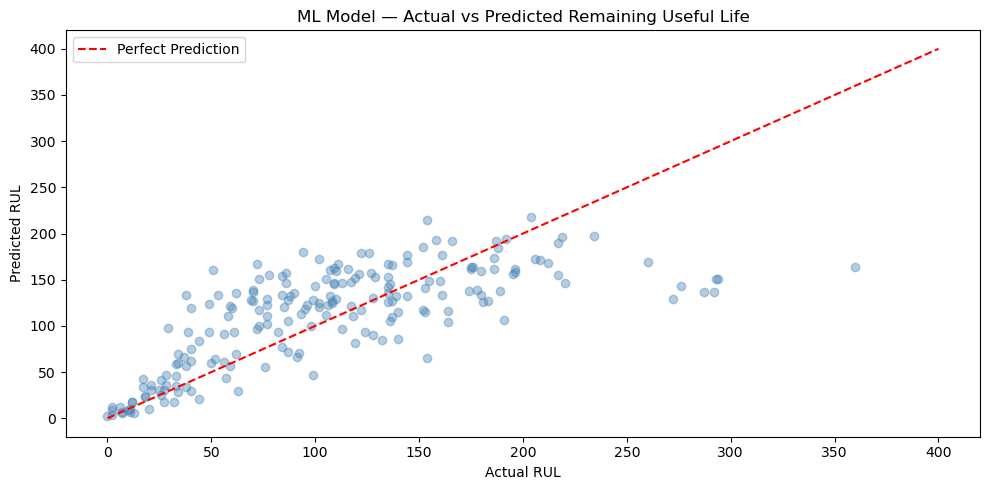

In [9]:
plt.figure(figsize=(10, 5))
plt.scatter(y_test[:200], predictions[:200], alpha=0.4, color='steelblue')
plt.plot([0, 400], [0, 400], color='red', linestyle='--', label='Perfect Prediction')
plt.xlabel('Actual RUL')
plt.ylabel('Predicted RUL')
plt.title('ML Model — Actual vs Predicted Remaining Useful Life')
plt.legend()
plt.tight_layout()
plt.savefig('ml_predictions.png')
plt.show()

C:\Users\chirag\AppData\Local\Temp\ipykernel_10984\2116668163.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance, x='Importance', y='Sensor', palette='viridis')


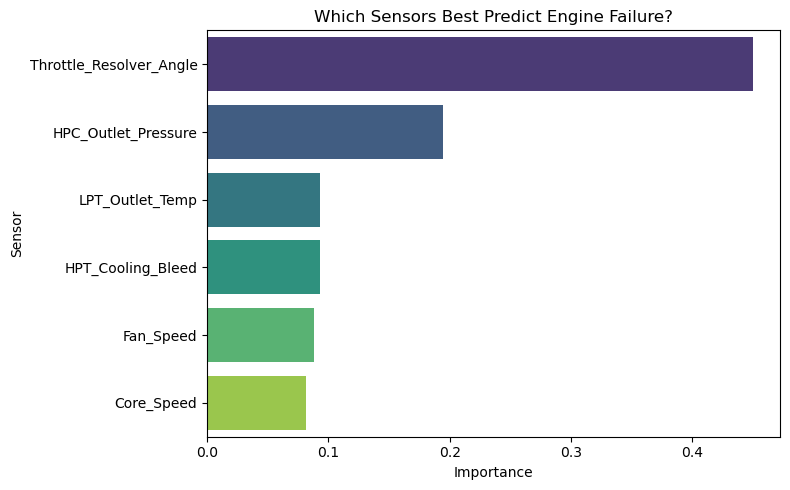

                    Sensor  Importance
4  Throttle_Resolver_Angle    0.449652
2      HPC_Outlet_Pressure    0.194444
1          LPT_Outlet_Temp    0.093271
5        HPT_Cooling_Bleed    0.092994
3                Fan_Speed    0.088126
0               Core_Speed    0.081513


In [10]:
importance = pd.DataFrame({
    'Sensor': features,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=importance, x='Importance', y='Sensor', palette='viridis')
plt.title('Which Sensors Best Predict Engine Failure?')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

print(importance)

In [1]:
!pip install xgboost scikit-learn

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 691.2 kB/s eta 0:02:27
   ---------------------------------------- 0.8/101.7 MB 791.8 kB/s eta 0:02:08
   ---------------------------------------- 1.0/101.7 MB 1.0 MB/s eta 0:01:37
    --------------------------------------- 2.1/101.

In [2]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Connect to MySQL Database
DB_USER = "root"
DB_PASSWORD = "root"   # Put your password here!
DB_HOST = "localhost"
DB_PORT = "3306"
DB_NAME = "hal_mro_analytics"

connection_string = f"mysql+pymysql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
db_engine = create_engine(connection_string)

print("📥 Fetching historical telemetry data from SQL view...")
df = pd.read_sql("SELECT * FROM calculated_engine_analytics ORDER BY Engine_ID, Current_Flight;", db_engine)

# ==========================================
# 🔥 STEP 2: ELITE TEMPORAL FEATURE ENGINEERING
# ==========================================
print("🛠️ Engineering advanced rolling temporal features...")

# We calculate window metrics over a 10-flight trailing period isolated by Engine_ID
window_size = 10

# A. Core Speed Rolling Metrics
df['Core_Speed_RollMean'] = df.groupby('Engine_ID')['Core_Speed'].transform(lambda x: x.rolling(window_size, min_periods=1).mean())
df['Core_Speed_RollStd'] = df.groupby('Engine_ID')['Core_Speed'].transform(lambda x: x.rolling(window_size, min_periods=1).std().fillna(0))

# B. Low-Pressure Turbine Outlet Temperature Rolling Metrics
df['LPT_Temp_RollMean'] = df.groupby('Engine_ID')['LPT_Outlet_Temp'].transform(lambda x: x.rolling(window_size, min_periods=1).mean())
df['LPT_Temp_RollStd'] = df.groupby('Engine_ID')['LPT_Outlet_Temp'].transform(lambda x: x.rolling(window_size, min_periods=1).std().fillna(0))

# C. High-Pressure Compressor Outlet Pressure Delta (Lag Feature)
# This calculates: Present_Reading - Reading_5_Flights_Ago
df['HPC_Pressure_Delta'] = df.groupby('Engine_ID')['HPC_Outlet_Pressure'].diff(periods=5).fillna(0)

print("✅ Feature Engineering complete. Added rolling statistics.")

# ==========================================
# 🤖 STEP 3: INDUSTRIAL TRAINING VIA XGBOOST
# ==========================================
# Define our elite feature space
elite_features = [
    'Core_Speed', 'Core_Speed_RollMean', 'Core_Speed_RollStd',
    'LPT_Outlet_Temp', 'LPT_Temp_RollMean', 'LPT_Temp_RollStd',
    'HPC_Outlet_Pressure', 'HPC_Pressure_Delta',
    'Fan_Speed', 'HPT_Cooling_Bleed'
]

X = df[elite_features]
y = df['Remaining_Useful_Life']

# Split data (80% training, 20% validation evaluation)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\n🤖 Booting up the XGBoost Hyper-Optimizer engine...")
# Initialize optimized extreme gradient booster
xg_regressor = xgb.XGBRegressor(
    n_estimators=150,
    max_depth=6,
    learning_rate=0.08,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xg_regressor.fit(X_train, y_train)
print("✅ XGBoost Model successfully optimized on fleet assets.")

# Evaluate accuracy
y_pred = xg_regressor.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\n📊 Elite Model Performance Audit:")
print(f"  - Mean Absolute Error (MAE): {mae:.2f} flights error margin")
print(f"  - R2 Fit Confidence Score: {r2:.4%}")

# ==========================================
# 💾 STEP 4: GENERATING THE ELITE PREDICTIONS OUTPUT
# ==========================================
# Inject predictions back into dataframe
df['AI_Predicted_RUL'] = xg_regressor.predict(X).astype(int)

# Force impossible negative predictions to be zero
df['AI_Predicted_RUL'] = df['AI_Predicted_RUL'].clip(lower=0)

# Calculate Model Deviation Variance (Actual SQL Countdown vs AI Prediction)
df['Prediction_Variance'] = df['Remaining_Useful_Life'] - df['AI_Predicted_RUL']

# Map out elite risk tracking categories
df['Elite_MRO_Status'] = np.where(df['AI_Predicted_RUL'] <= 25, 'CRITICAL DISPATCH (Red)',
                          np.where(df['AI_Predicted_RUL'] <= 75, 'MAINTENANCE DUE (Yellow)', 'FLIGHT READY (Green)'))

print("\n💾 Overwriting database data-mart with Elite ML Data...")
df.to_sql('elite_mro_predictions', db_engine, if_exists='replace', index=False)
print("🚀 Elite Data Pipeline successfully deployed back to MySQL server!")

📥 Fetching historical telemetry data from SQL view...
🛠️ Engineering advanced rolling temporal features...
✅ Feature Engineering complete. Added rolling statistics.

🤖 Booting up the XGBoost Hyper-Optimizer engine...
✅ XGBoost Model successfully optimized on fleet assets.

📊 Elite Model Performance Audit:
  - Mean Absolute Error (MAE): 32.13 flights error margin
  - R2 Fit Confidence Score: 58.8590%

💾 Overwriting database data-mart with Elite ML Data...
🚀 Elite Data Pipeline successfully deployed back to MySQL server!
